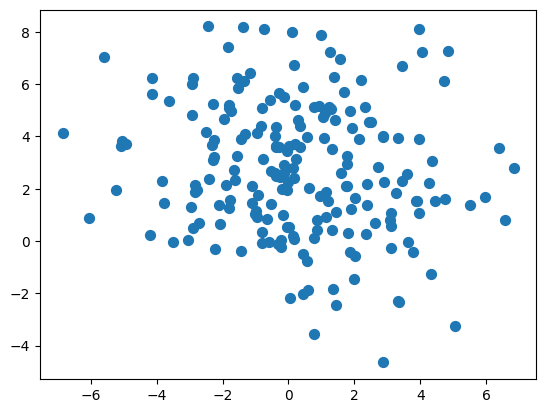

[2 0 0 2 0 1 1 0 0 2 0 2 0 1 2 2 1 1 2 2 2 1 0 0 2 2 1 2 0 2 1 0 2 2 1 1 0
 1 1 2 1 2 2 0 0 0 0 1 0 0 2 1 2 0 2 2 1 1 0 0 2 0 0 1 1 2 2 2 2 0 1 0 0 2
 0 2 1 1 1 2 2 0 0 1 1 1 2 2 0 1 2 1 1 2 1 0 1 2 2 1 1 0 2 2 2 2 1 0 2 0 2
 1 1 0 0 0 1 1 2 2 1 1 1 1 1 2 2 2 2 0 2 2 2 2 0 1 1 0 1 2 2 2 0 1 1 0 2 2
 1 0 1 2 2 2 0 1 1 1 0 0 1 2 2 2 0 0 1 0 1 2 2 1 0 1 2 2 1 2 0 2 0 2 1 1 1
 1 2 1 0 0 0 2 2 1 2 1 2 1 1 1]


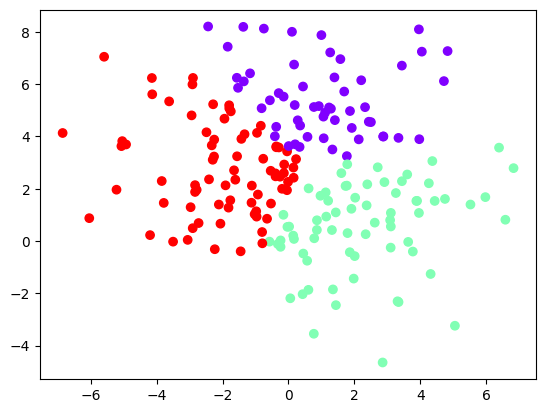

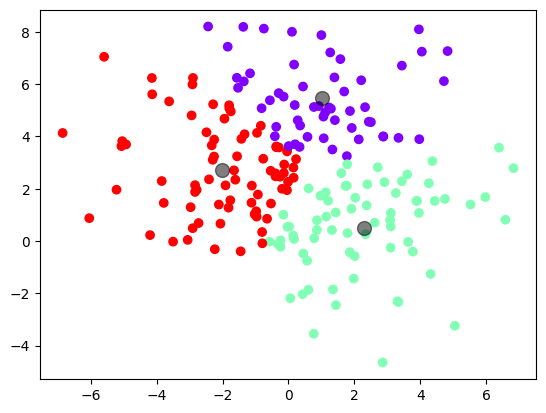

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets._samples_generator import make_blobs

# generate random data
np.random.seed(0)
X, y = make_blobs(n_samples=200, centers=3, n_features=2, cluster_std=2, random_state=0)

# plot the data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.show()

# create the k-means model
kmeans = KMeans(n_clusters=3, random_state=0)

# fit the model to the data
kmeans.fit(X)

# print the cluster labels
print(kmeans.labels_)

# plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='rainbow')
plt.show()

# plot the clusters with centroids
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=100, alpha=0.5)
plt.show()

In [19]:
# Lab 12 RNN
import torch
import torch.nn as nn
from torch.autograd import Variable

torch.manual_seed(777)  # reproducibility


idx2char = ['h', 'i', 'e', 'l', 'o']

# Teach hihell -> ihello
x_data = [[0, 1, 0, 2, 3, 3]]   # hihell
y_data = [1, 0, 2, 3, 3, 4]    # ihello

# As we have one batch of samples, we will change them to variables only once
inputs = Variable(torch.LongTensor(x_data))
labels = Variable(torch.LongTensor(y_data))

vocab_size = 5
embedding_size = 10  # embedding size
hidden_size = 5  # output from the LSTM. 5 to directly predict one-hot
batch_size = 1   # one sentence
sequence_length = 6  # |ihello| == 6
num_layers = 1  # one-layer rnn


class Model(nn.Module):

    def __init__(self, hidden_size):
        super(Model, self).__init__()

        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.rnn       = nn.RNN(input_size=embedding_size, hidden_size=5, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # Initialize hidden and cell states
        # (num_layers * num_directions, batch, hidden_size)
        h_0 = Variable(torch.zeros(1, x.size(0), self.hidden_size))

        emb = self.embedding(x)
        emb = emb.view(batch_size, sequence_length, -1)

        # Propagate embedding through RNN
        # Input: (batch, seq_len, embedding_size)
        # h_0: (num_layers * num_directions, batch, hidden_size)
        out, _ = self.rnn(emb, h_0)
        return self.fc(out.view(-1, vocab_size))


# Instantiate RNN model
model = Model(hidden_size)
print(model)

# Set loss and optimizer function
# CrossEntropyLoss = LogSoftmax + NLLLoss
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Train the model
for epoch in range(100):
    outputs = model(inputs)
    optimizer.zero_grad()
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    _, idx = outputs.max(1)
    idx = idx.data.numpy()
    result_str = [idx2char[c] for c in idx.squeeze()]
    print("epoch: %d, loss: %1.3f" % (epoch + 1, loss.item()))
    print("Predicted string: ", ''.join(result_str))

print("Learning finished!")

Model(
  (embedding): Embedding(5, 10)
  (rnn): RNN(10, 5, batch_first=True)
  (fc): Linear(in_features=5, out_features=5, bias=True)
)
epoch: 1, loss: 1.768
Predicted string:  eheohh
epoch: 2, loss: 1.396
Predicted string:  oheiii
epoch: 3, loss: 1.132
Predicted string:  iheloo
epoch: 4, loss: 0.949
Predicted string:  ihello
epoch: 5, loss: 0.798
Predicted string:  ihelll
epoch: 6, loss: 0.659
Predicted string:  ihelll
epoch: 7, loss: 0.547
Predicted string:  ihelll
epoch: 8, loss: 0.449
Predicted string:  ihelll
epoch: 9, loss: 0.384
Predicted string:  ihelll
epoch: 10, loss: 0.343
Predicted string:  ihello
epoch: 11, loss: 0.304
Predicted string:  ihello
epoch: 12, loss: 0.235
Predicted string:  ihello
epoch: 13, loss: 0.227
Predicted string:  ihello
epoch: 14, loss: 0.239
Predicted string:  iheloo
epoch: 15, loss: 0.233
Predicted string:  iheloo
epoch: 16, loss: 0.147
Predicted string:  ihello
epoch: 17, loss: 0.320
Predicted string:  ihelll
epoch: 18, loss: 0.139
Predicted string: